In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DRIVE_PATH = '/content/drive/MyDrive'
OUTPUT_DIR = os.path.join(DRIVE_PATH, 'model_3_optimized_outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Output directory:', OUTPUT_DIR)
print('TensorFlow version:', tf.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output directory: /content/drive/MyDrive/model_3_optimized_outputs
TensorFlow version: 2.20.0


In [3]:
def find_file_in_drive(candidate_names, required=True):
    available_files = os.listdir(DRIVE_PATH)
    lower_map = {f.lower(): f for f in available_files}

    for name in candidate_names:
        if name.lower() in lower_map:
            return os.path.join(DRIVE_PATH, lower_map[name.lower()])

    for f in available_files:
        f_lower = f.lower()
        for name in candidate_names:
            base = name.lower().replace('.csv', '').replace('.xlsx', '')
            if base in f_lower:
                return os.path.join(DRIVE_PATH, f)

    if required:
        print('Available files in MyDrive:')
        for f in available_files[:100]:
            print(' -', f)
        raise FileNotFoundError(f'None of these candidate files were found: {candidate_names}')
    return None

CATEGORY_FILE = find_file_in_drive([
    'model_ready_category.csv',
    'model_ready_category.xlsx',
    'model_ready_category_level.csv',
    'model_ready_category_level.xlsx',
    'category_model_ready.csv',
    'category_model_ready.xlsx',
    'model_ready_category_dataset.csv',
    'model_ready_category_dataset.xlsx'
])

MODEL_1_FILE = find_file_in_drive([
    'model_1_test_results.csv',
    'model1_test_results.csv',
    'model_1_final_test_results.csv',
    'model_1_selected_test_results.csv'
], required=False)

MODEL_2_FILE = find_file_in_drive([
    'model_2_test_results.csv',
    'model2_test_results.csv',
    'model_2_final_test_results.csv',
    'model_2_option_a_test_results.csv',
    'model_2_selected_test_results.csv'
], required=False)

print('Category file:', CATEGORY_FILE)
print('Model 1 comparison file:', MODEL_1_FILE)
print('Model 2 comparison file:', MODEL_2_FILE)

Category file: /content/drive/MyDrive/model_ready_category_dataset.csv
Model 1 comparison file: None
Model 2 comparison file: None


In [5]:
if CATEGORY_FILE.lower().endswith('.xlsx'):
    category_df = pd.read_excel(CATEGORY_FILE)
else:
    category_df = pd.read_csv(CATEGORY_FILE)

if 'week_start' in category_df.columns:
    category_df['week_start'] = pd.to_datetime(category_df['week_start'])
elif 'Week' in category_df.columns:
    category_df = category_df.rename(columns={'Week': 'week_start'})
    category_df['week_start'] = pd.to_datetime(category_df['week_start'])
elif 'week' in category_df.columns:
    category_df = category_df.rename(columns={'week': 'week_start'})
    category_df['week_start'] = pd.to_datetime(category_df['week_start'])
else:
    raise ValueError('Expected week_start, Week, or week column.')

if 'Product Category' not in category_df.columns:
    category_candidates = [c for c in category_df.columns if 'category' in c.lower()]
    if len(category_candidates) > 0:
        category_df = category_df.rename(columns={category_candidates[0]: 'Product Category'})
    else:
        raise ValueError('Expected Product Category column.')

if 'weekly_quantity' not in category_df.columns:
    qty_candidates = [c for c in category_df.columns if 'quantity' in c.lower()]
    if len(qty_candidates) > 0:
        category_df = category_df.rename(columns={qty_candidates[0]: 'weekly_quantity'})
    else:
        raise ValueError('Expected weekly_quantity column.')

category_df = category_df.sort_values(['Product Category', 'week_start']).reset_index(drop=True)
category_df['weekly_quantity'] = category_df['weekly_quantity'].clip(lower=0)

print('Dataset shape:', category_df.shape)
print('Date range:', category_df['week_start'].min(), 'to', category_df['week_start'].max())
print('Categories:', category_df['Product Category'].nunique())
print('Total demand:', category_df['weekly_quantity'].sum())

Dataset shape: (6200, 44)
Date range: 2023-01-09 00:00:00 to 2025-12-22 00:00:00
Categories: 40
Total demand: 530935.0


In [6]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denom != 0
    if mask.sum() == 0:
        return 0.0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

def mase(y_true, y_pred, y_train, seasonality=52):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_train = np.asarray(y_train, dtype=float)

    if len(y_train) > seasonality:
        scale = np.mean(np.abs(y_train[seasonality:] - y_train[:-seasonality]))
    elif len(y_train) > 1:
        scale = np.mean(np.abs(np.diff(y_train)))
    else:
        scale = np.nan

    if scale == 0 or np.isnan(scale):
        scale = np.mean(np.abs(y_train))

    if scale == 0 or np.isnan(scale):
        return np.nan

    return np.mean(np.abs(y_true - y_pred)) / scale

def compute_metrics(y_true, y_pred, y_train):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.maximum(np.asarray(y_pred, dtype=float), 0)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'sMAPE': smape(y_true, y_pred),
        'MASE': mase(y_true, y_pred, y_train)
    }

In [7]:
def add_time_features(df):
    df = df.copy()
    df['week_of_year'] = df['week_start'].dt.isocalendar().week.astype(int)
    df['month'] = df['week_start'].dt.month.astype(int)
    df['quarter'] = df['week_start'].dt.quarter.astype(int)
    df['year'] = df['week_start'].dt.year.astype(int)
    df['week_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    return df

def add_lag_features(df):
    df = df.copy()
    lag_values = [1, 2, 4, 8, 12, 26, 52]
    rolling_windows = [4, 8, 12, 26]

    for lag in lag_values:
        df[f'lag_{lag}'] = df.groupby('Product Category')['weekly_quantity'].shift(lag)

    for window in rolling_windows:
        shifted = df.groupby('Product Category')['weekly_quantity'].shift(1)
        df[f'rolling_mean_{window}'] = shifted.groupby(df['Product Category']).rolling(window).mean().reset_index(level=0, drop=True)
        df[f'rolling_std_{window}'] = shifted.groupby(df['Product Category']).rolling(window).std().reset_index(level=0, drop=True)
        df[f'recent_zero_ratio_{window}'] = shifted.groupby(df['Product Category']).rolling(window).apply(lambda x: np.mean(np.asarray(x) == 0), raw=False).reset_index(level=0, drop=True)
        df[f'recent_positive_ratio_{window}'] = shifted.groupby(df['Product Category']).rolling(window).apply(lambda x: np.mean(np.asarray(x) > 0), raw=False).reset_index(level=0, drop=True)

    zero_streaks = []
    for _, group in df.groupby('Product Category', sort=False):
        values = group['weekly_quantity'].shift(1).fillna(0).values
        count = 0
        local_streak = []
        for value in values:
            if value == 0:
                count += 1
            else:
                count = 0
            local_streak.append(count)
        zero_streaks.extend(local_streak)
    df['zero_streak'] = zero_streaks

    return df

category_df = add_time_features(category_df)
category_df = add_lag_features(category_df)

numeric_cols = category_df.select_dtypes(include=[np.number]).columns.tolist()
category_df[numeric_cols] = category_df[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

category_encoder = OrdinalEncoder(dtype=int)
category_df['category_id'] = category_encoder.fit_transform(category_df[['Product Category']]).astype(int)

category_mapping = pd.DataFrame({
    'Product Category': category_encoder.categories_[0],
    'category_id': range(len(category_encoder.categories_[0]))
})
category_mapping.to_csv(os.path.join(OUTPUT_DIR, 'model_3_category_mapping.csv'), index=False, encoding='utf-8-sig')

excluded_cols = ['week_start', 'Product Category', 'weekly_quantity', 'category_id']
feature_cols = [
    c for c in category_df.columns
    if c not in excluded_cols
    and pd.api.types.is_numeric_dtype(category_df[c])
    and c != 'category_encoded'
]

print('Number of continuous features:', len(feature_cols))
print(feature_cols)

Number of continuous features: 41
['weekly_revenue', 'transaction_count', 'unique_skus', 'unique_customers', 'avg_unit_price', 'avg_gross_margin_pct', 'negative_margin_share', 'from_china_share', 'from_india_share', 'year', 'month', 'quarter', 'week_of_year', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_12', 'lag_26', 'lag_52', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'rolling_std_8', 'rolling_mean_12', 'rolling_std_12', 'rolling_mean_26', 'rolling_std_26', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'recent_zero_ratio_4', 'recent_positive_ratio_4', 'recent_zero_ratio_8', 'recent_positive_ratio_8', 'recent_zero_ratio_12', 'recent_positive_ratio_12', 'recent_zero_ratio_26', 'recent_positive_ratio_26', 'zero_streak']


In [8]:
split_scenarios = []
for val_horizon in [4, 8, 12]:
    for test_horizon in [4, 8, 12]:
        split_scenarios.append({
            'scenario': f'val_{val_horizon}_test_{test_horizon}',
            'validation_horizon': val_horizon,
            'test_horizon': test_horizon
        })

REPRESENTATIVE_SCENARIO = 'val_8_test_8'

print('Split scenarios:')
for s in split_scenarios:
    print(s)

Split scenarios:
{'scenario': 'val_4_test_4', 'validation_horizon': 4, 'test_horizon': 4}
{'scenario': 'val_4_test_8', 'validation_horizon': 4, 'test_horizon': 8}
{'scenario': 'val_4_test_12', 'validation_horizon': 4, 'test_horizon': 12}
{'scenario': 'val_8_test_4', 'validation_horizon': 8, 'test_horizon': 4}
{'scenario': 'val_8_test_8', 'validation_horizon': 8, 'test_horizon': 8}
{'scenario': 'val_8_test_12', 'validation_horizon': 8, 'test_horizon': 12}
{'scenario': 'val_12_test_4', 'validation_horizon': 12, 'test_horizon': 4}
{'scenario': 'val_12_test_8', 'validation_horizon': 12, 'test_horizon': 8}
{'scenario': 'val_12_test_12', 'validation_horizon': 12, 'test_horizon': 12}


In [9]:
def transform_target(y, method):
    if method == 'log1p':
        return np.log1p(np.maximum(y, 0))
    return y

def inverse_transform_target(y, method):
    if method == 'log1p':
        return np.expm1(y)
    return y

def get_split_dates(df, validation_horizon, test_horizon):
    all_weeks = np.array(sorted(df['week_start'].unique()))
    test_start = all_weeks[-test_horizon]
    validation_start = all_weeks[-(validation_horizon + test_horizon)]
    return pd.Timestamp(validation_start), pd.Timestamp(test_start)


def create_direct_sequences(df, feature_cols, lookback, horizon, target_transform):
    X_num, X_cat, y, meta = [], [], [], []

    for category, group in df.groupby('Product Category'):
        group = group.sort_values('week_start').reset_index(drop=True)
        values_num = group[feature_cols].values.astype(float)
        values_target = group['weekly_quantity'].values.astype(float)
        category_ids = group['category_id'].values.astype(int)
        weeks = group['week_start'].values

        for i in range(lookback, len(group) - horizon + 1):
            X_num.append(values_num[i-lookback:i])
            X_cat.append(category_ids[i-1])
            y.append(transform_target(values_target[i:i+horizon], target_transform))
            meta.append({
                'Product Category': category,
                'forecast_start': pd.Timestamp(weeks[i]),
                'forecast_end': pd.Timestamp(weeks[i+horizon-1])
            })

    return np.array(X_num), np.array(X_cat), np.array(y), pd.DataFrame(meta)

In [10]:
def build_model(architecture, lookback, n_features, n_categories, horizon, units, dropout, lr, embedding_dim):
    numeric_input = layers.Input(shape=(lookback, n_features), name='numeric_sequence')
    category_input = layers.Input(shape=(), dtype='int32', name='category_id')

    emb = layers.Embedding(input_dim=n_categories, output_dim=embedding_dim, name='category_embedding')(category_input)
    emb_rep = layers.RepeatVector(lookback)(emb)
    x = layers.Concatenate(axis=-1)([numeric_input, emb_rep])

    if architecture == 'gru':
        x = layers.GRU(units, return_sequences=False)(x)
    elif architecture == 'lstm':
        x = layers.LSTM(units, return_sequences=False)(x)
    elif architecture == 'stacked_gru':
        x = layers.GRU(units, return_sequences=True)(x)
        if dropout > 0:
            x = layers.Dropout(dropout)(x)
        x = layers.GRU(max(units // 2, 16), return_sequences=False)(x)
    elif architecture == 'stacked_lstm':
        x = layers.LSTM(units, return_sequences=True)(x)
        if dropout > 0:
            x = layers.Dropout(dropout)(x)
        x = layers.LSTM(max(units // 2, 16), return_sequences=False)(x)
    else:
        raise ValueError(f'Unknown architecture: {architecture}')

    if dropout > 0:
        x = layers.Dropout(dropout)(x)

    x = layers.Dense(64, activation='relu')(x)
    output = layers.Dense(horizon, activation='linear')(x)

    model = Model(inputs=[numeric_input, category_input], outputs=output)
    model.compile(optimizer=Adam(learning_rate=lr), loss='mae')
    return model

In [11]:
architecture_search_grid = [
    {'architecture': 'gru', 'lookback': 8, 'units': 64, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'log1p', 'embedding_dim': 4},
    {'architecture': 'gru', 'lookback': 12, 'units': 64, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'log1p', 'embedding_dim': 4},
    {'architecture': 'gru', 'lookback': 16, 'units': 128, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'log1p', 'embedding_dim': 8},
    {'architecture': 'gru', 'lookback': 24, 'units': 128, 'dropout': 0.3, 'lr': 0.0005, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'log1p', 'embedding_dim': 8},

    {'architecture': 'lstm', 'lookback': 8, 'units': 64, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'log1p', 'embedding_dim': 4},
    {'architecture': 'lstm', 'lookback': 12, 'units': 64, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'log1p', 'embedding_dim': 4},
    {'architecture': 'lstm', 'lookback': 16, 'units': 128, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'log1p', 'embedding_dim': 8},

    {'architecture': 'stacked_gru', 'lookback': 12, 'units': 128, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'log1p', 'embedding_dim': 8},
    {'architecture': 'stacked_gru', 'lookback': 16, 'units': 128, 'dropout': 0.3, 'lr': 0.0005, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'log1p', 'embedding_dim': 8},

    {'architecture': 'stacked_lstm', 'lookback': 12, 'units': 128, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'log1p', 'embedding_dim': 8},
    {'architecture': 'stacked_lstm', 'lookback': 16, 'units': 128, 'dropout': 0.3, 'lr': 0.0005, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'log1p', 'embedding_dim': 8},

    {'architecture': 'gru', 'lookback': 12, 'units': 64, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'scaler': 'minmax', 'target_transform': 'log1p', 'embedding_dim': 4},
    {'architecture': 'lstm', 'lookback': 12, 'units': 64, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'scaler': 'minmax', 'target_transform': 'log1p', 'embedding_dim': 4},

    {'architecture': 'gru', 'lookback': 12, 'units': 64, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'raw', 'embedding_dim': 4},
    {'architecture': 'lstm', 'lookback': 12, 'units': 64, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'raw', 'embedding_dim': 4},
]

pd.DataFrame(architecture_search_grid).to_csv(
    os.path.join(OUTPUT_DIR, 'model_3_phase_a_architecture_search_grid.csv'),
    index=False,
    encoding='utf-8-sig'
)

print('Phase A experiments:', len(architecture_search_grid))

Phase A experiments: 15


In [12]:
phase_a_results = []
phase_a_training_logs = []
n_categories = category_df['category_id'].nunique()

rep_split = [s for s in split_scenarios if s['scenario'] == REPRESENTATIVE_SCENARIO][0]
rep_val_start, rep_test_start = get_split_dates(
    category_df,
    rep_split['validation_horizon'],
    rep_split['test_horizon']
)

print('\nPHASE A: Architecture search on representative scenario:', REPRESENTATIVE_SCENARIO)
print('Validation start:', rep_val_start)
print('Test start:', rep_test_start)

for experiment_id, config in enumerate(architecture_search_grid, start=1):
    print(f"\nPhase A experiment {experiment_id}/{len(architecture_search_grid)}: {config}")

    tf.keras.backend.clear_session()

    train_df = category_df[category_df['week_start'] < rep_val_start].copy()

    scaler = StandardScaler() if config['scaler'] == 'standard' else MinMaxScaler()
    scaler.fit(train_df[feature_cols])

    scaled_df = category_df.copy()
    scaled_df[feature_cols] = scaler.transform(scaled_df[feature_cols])

    X_num, X_cat, y, meta = create_direct_sequences(
        scaled_df,
        feature_cols,
        lookback=config['lookback'],
        horizon=rep_split['test_horizon'],
        target_transform=config['target_transform']
    )

    train_mask = meta['forecast_start'] < rep_val_start
    val_mask = (meta['forecast_start'] >= rep_val_start) & (meta['forecast_start'] < rep_test_start)

    if train_mask.sum() == 0 or val_mask.sum() == 0:
        print('Skipped because there are not enough sequences.')
        continue

    X_train_num, X_train_cat, y_train = X_num[train_mask], X_cat[train_mask], y[train_mask]
    X_val_num, X_val_cat, y_val = X_num[val_mask], X_cat[val_mask], y[val_mask]
    meta_val = meta[val_mask].reset_index(drop=True)

    model = build_model(
        architecture=config['architecture'],
        lookback=config['lookback'],
        n_features=len(feature_cols),
        n_categories=n_categories,
        horizon=rep_split['test_horizon'],
        units=config['units'],
        dropout=config['dropout'],
        lr=config['lr'],
        embedding_dim=config['embedding_dim']
    )

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=1e-5)
    ]

    history = model.fit(
        [X_train_num, X_train_cat],
        y_train,
        validation_data=([X_val_num, X_val_cat], y_val),
        epochs=50,
        batch_size=config['batch_size'],
        callbacks=callbacks,
        verbose=0
    )

    y_val_pred = model.predict([X_val_num, X_val_cat], verbose=0)
    y_val_pred = inverse_transform_target(y_val_pred, config['target_transform'])
    y_val_actual = inverse_transform_target(y_val, config['target_transform'])
    y_val_pred = np.maximum(y_val_pred, 0)

    category_metrics = []
    for category in meta_val['Product Category'].unique():
        idx = meta_val['Product Category'] == category
        actual = y_val_actual[idx].reshape(-1)
        pred = y_val_pred[idx].reshape(-1)
        y_train_category = train_df.loc[train_df['Product Category'] == category, 'weekly_quantity'].values
        metrics = compute_metrics(actual, pred, y_train_category)
        category_metrics.append(metrics)

    metrics_df = pd.DataFrame(category_metrics)
    mean_mase = metrics_df['MASE'].replace([np.inf, -np.inf], np.nan).mean()
    median_mase = metrics_df['MASE'].replace([np.inf, -np.inf], np.nan).median()

    phase_a_results.append({
        'phase': 'A_architecture_search',
        'representative_scenario': REPRESENTATIVE_SCENARIO,
        'experiment_id': experiment_id,
        'mean_validation_MASE': mean_mase,
        'median_validation_MASE': median_mase,
        'epochs_ran': len(history.history['loss']),
        'final_train_loss': history.history['loss'][-1],
        'final_validation_loss': history.history['val_loss'][-1],
        **config
    })

    phase_a_training_logs.append({
        'experiment_id': experiment_id,
        'loss_history': history.history['loss'],
        'val_loss_history': history.history['val_loss'],
        **config
    })

    print(f'Mean validation MASE: {mean_mase:.4f} | Median validation MASE: {median_mase:.4f}')

phase_a_results_df = pd.DataFrame(phase_a_results).sort_values('mean_validation_MASE')
phase_a_results_df.to_csv(os.path.join(OUTPUT_DIR, 'model_3_phase_a_results.csv'), index=False, encoding='utf-8-sig')

with open(os.path.join(OUTPUT_DIR, 'model_3_phase_a_training_logs.json'), 'w', encoding='utf-8') as f:
    json.dump(phase_a_training_logs, f, ensure_ascii=False, indent=2)

print('\nTop Phase A configurations:')
print(phase_a_results_df.head(5))


PHASE A: Architecture search on representative scenario: val_8_test_8
Validation start: 2025-09-08 00:00:00
Test start: 2025-11-03 00:00:00

Phase A experiment 1/15: {'architecture': 'gru', 'lookback': 8, 'units': 64, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'log1p', 'embedding_dim': 4}
Mean validation MASE: 0.8446 | Median validation MASE: 0.4038

Phase A experiment 2/15: {'architecture': 'gru', 'lookback': 12, 'units': 64, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'log1p', 'embedding_dim': 4}
Mean validation MASE: 0.6313 | Median validation MASE: 0.2716

Phase A experiment 3/15: {'architecture': 'gru', 'lookback': 16, 'units': 128, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'log1p', 'embedding_dim': 8}
Mean validation MASE: 0.6861 | Median validation MASE: 0.3451

Phase A experiment 4/15: {'architecture': 'gru', 'lookback': 24, 'units': 128, 'd

In [13]:
TOP_N_CONFIGS = 3
phase_b_grid = phase_a_results_df.head(TOP_N_CONFIGS)[[
    'architecture', 'lookback', 'units', 'dropout', 'lr', 'batch_size', 'scaler', 'target_transform', 'embedding_dim'
]].to_dict('records')

pd.DataFrame(phase_b_grid).to_csv(
    os.path.join(OUTPUT_DIR, 'model_3_phase_b_selected_grid.csv'),
    index=False,
    encoding='utf-8-sig'
)

print('\nPhase B selected configurations:')
for cfg in phase_b_grid:
    print(cfg)


Phase B selected configurations:
{'architecture': 'lstm', 'lookback': 16, 'units': 128, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'log1p', 'embedding_dim': 8}
{'architecture': 'gru', 'lookback': 24, 'units': 128, 'dropout': 0.3, 'lr': 0.0005, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'log1p', 'embedding_dim': 8}
{'architecture': 'stacked_lstm', 'lookback': 16, 'units': 128, 'dropout': 0.3, 'lr': 0.0005, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'log1p', 'embedding_dim': 8}


In [14]:
phase_b_validation_results = []
phase_b_test_results = []
phase_b_best_configs = []
forecast_rows = []
phase_b_training_logs = []

for split in split_scenarios:
    scenario = split['scenario']
    val_horizon = split['validation_horizon']
    test_horizon = split['test_horizon']
    horizon = test_horizon

    print(f'PHASE B scenario: {scenario}')

    val_start, test_start = get_split_dates(category_df, val_horizon, test_horizon)
    train_df = category_df[category_df['week_start'] < val_start].copy()
    train_val_df = category_df[category_df['week_start'] < test_start].copy()
    test_df = category_df[category_df['week_start'] >= test_start].copy()

    scenario_records = []

    for experiment_id, config in enumerate(phase_b_grid, start=1):
        print(f"Scenario {scenario} | Config {experiment_id}/{len(phase_b_grid)}")
        tf.keras.backend.clear_session()

        scaler = StandardScaler() if config['scaler'] == 'standard' else MinMaxScaler()
        scaler.fit(train_df[feature_cols])

        scaled_df = category_df.copy()
        scaled_df[feature_cols] = scaler.transform(scaled_df[feature_cols])

        X_num, X_cat, y, meta = create_direct_sequences(
            scaled_df,
            feature_cols,
            lookback=int(config['lookback']),
            horizon=horizon,
            target_transform=config['target_transform']
        )

        train_mask = meta['forecast_start'] < val_start
        val_mask = (meta['forecast_start'] >= val_start) & (meta['forecast_start'] < test_start)

        if train_mask.sum() == 0 or val_mask.sum() == 0:
            continue

        X_train_num, X_train_cat, y_train = X_num[train_mask], X_cat[train_mask], y[train_mask]
        X_val_num, X_val_cat, y_val = X_num[val_mask], X_cat[val_mask], y[val_mask]
        meta_val = meta[val_mask].reset_index(drop=True)

        model = build_model(
            architecture=config['architecture'],
            lookback=int(config['lookback']),
            n_features=len(feature_cols),
            n_categories=n_categories,
            horizon=horizon,
            units=int(config['units']),
            dropout=float(config['dropout']),
            lr=float(config['lr']),
            embedding_dim=int(config['embedding_dim'])
        )

        callbacks = [
            EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=1e-5)
        ]

        history = model.fit(
            [X_train_num, X_train_cat],
            y_train,
            validation_data=([X_val_num, X_val_cat], y_val),
            epochs=50,
            batch_size=int(config['batch_size']),
            callbacks=callbacks,
            verbose=0
        )

        y_val_pred = model.predict([X_val_num, X_val_cat], verbose=0)
        y_val_pred = inverse_transform_target(y_val_pred, config['target_transform'])
        y_val_actual = inverse_transform_target(y_val, config['target_transform'])
        y_val_pred = np.maximum(y_val_pred, 0)

        category_metrics = []
        for category in meta_val['Product Category'].unique():
            idx = meta_val['Product Category'] == category
            actual = y_val_actual[idx].reshape(-1)
            pred = y_val_pred[idx].reshape(-1)
            y_train_category = train_df.loc[train_df['Product Category'] == category, 'weekly_quantity'].values
            metrics = compute_metrics(actual, pred, y_train_category)
            metrics.update({
                'scenario': scenario,
                'experiment_id': experiment_id,
                'Product Category': category,
                **config
            })
            category_metrics.append(metrics)

        category_metrics_df = pd.DataFrame(category_metrics)
        mean_val_mase = category_metrics_df['MASE'].replace([np.inf, -np.inf], np.nan).mean()
        median_val_mase = category_metrics_df['MASE'].replace([np.inf, -np.inf], np.nan).median()

        phase_b_validation_results.extend(category_metrics)

        record = {
            'scenario': scenario,
            'experiment_id': experiment_id,
            'mean_validation_MASE': mean_val_mase,
            'median_validation_MASE': median_val_mase,
            'epochs_ran': len(history.history['loss']),
            'final_train_loss': history.history['loss'][-1],
            'final_validation_loss': history.history['val_loss'][-1],
            **config
        }
        scenario_records.append(record)
        phase_b_training_logs.append(record)

        print(f'Validation MASE: {mean_val_mase:.4f}')

    scenario_records_df = pd.DataFrame(scenario_records)
    if scenario_records_df.empty:
        print(f'No valid configuration for scenario {scenario}.')
        continue

    best_row = scenario_records_df.sort_values('mean_validation_MASE').iloc[0].to_dict()
    phase_b_best_configs.append(best_row)
    best_config = {k: best_row[k] for k in phase_b_grid[0].keys()}

    print('Selected best config for scenario:', best_config)

    tf.keras.backend.clear_session()

    scaler = StandardScaler() if best_config['scaler'] == 'standard' else MinMaxScaler()
    scaler.fit(train_val_df[feature_cols])

    scaled_df = category_df.copy()
    scaled_df[feature_cols] = scaler.transform(scaled_df[feature_cols])

    X_num, X_cat, y, meta = create_direct_sequences(
        scaled_df,
        feature_cols,
        lookback=int(best_config['lookback']),
        horizon=horizon,
        target_transform=best_config['target_transform']
    )

    train_val_mask = meta['forecast_start'] < test_start
    test_mask = meta['forecast_start'] == test_start

    X_tv_num, X_tv_cat, y_tv = X_num[train_val_mask], X_cat[train_val_mask], y[train_val_mask]
    X_test_num, X_test_cat, y_test = X_num[test_mask], X_cat[test_mask], y[test_mask]
    meta_test = meta[test_mask].reset_index(drop=True)

    if len(X_test_num) == 0:
        print('No test sequences available for this scenario.')
        continue

    internal_val_size = max(1, int(0.15 * len(X_tv_num)))
    X_train_final_num = X_tv_num[:-internal_val_size]
    X_train_final_cat = X_tv_cat[:-internal_val_size]
    y_train_final = y_tv[:-internal_val_size]
    X_internal_val_num = X_tv_num[-internal_val_size:]
    X_internal_val_cat = X_tv_cat[-internal_val_size:]
    y_internal_val = y_tv[-internal_val_size:]

    final_model = build_model(
        architecture=best_config['architecture'],
        lookback=int(best_config['lookback']),
        n_features=len(feature_cols),
        n_categories=n_categories,
        horizon=horizon,
        units=int(best_config['units']),
        dropout=float(best_config['dropout']),
        lr=float(best_config['lr']),
        embedding_dim=int(best_config['embedding_dim'])
    )

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', patience=4, factor=0.5, min_lr=1e-5)
    ]

    final_history = final_model.fit(
        [X_train_final_num, X_train_final_cat],
        y_train_final,
        validation_data=([X_internal_val_num, X_internal_val_cat], y_internal_val),
        epochs=70,
        batch_size=int(best_config['batch_size']),
        callbacks=callbacks,
        verbose=0
    )

    y_test_pred = final_model.predict([X_test_num, X_test_cat], verbose=0)
    y_test_pred = inverse_transform_target(y_test_pred, best_config['target_transform'])
    y_test_actual = inverse_transform_target(y_test, best_config['target_transform'])
    y_test_pred = np.maximum(y_test_pred, 0)

    forecast_weeks = sorted(test_df['week_start'].unique())[:horizon]

    for row_idx, row in meta_test.iterrows():
        category = row['Product Category']
        actual_values = y_test_actual[row_idx]
        pred_values = y_test_pred[row_idx]
        y_train_category = train_val_df.loc[train_val_df['Product Category'] == category, 'weekly_quantity'].values

        metrics = compute_metrics(actual_values, pred_values, y_train_category)
        phase_b_test_results.append({
            'scenario': scenario,
            'Product Category': category,
            **metrics,
            **best_config
        })

        for h, week in enumerate(forecast_weeks):
            forecast_rows.append({
                'scenario': scenario,
                'Product Category': category,
                'week_start': week,
                'horizon_step': h + 1,
                'actual': actual_values[h],
                'forecast': pred_values[h],
                **best_config
            })

PHASE B scenario: val_4_test_4
Scenario val_4_test_4 | Config 1/3
Validation MASE: 0.1402
Scenario val_4_test_4 | Config 2/3
Validation MASE: 0.1419
Scenario val_4_test_4 | Config 3/3
Validation MASE: 0.1482
Selected best config for scenario: {'architecture': 'lstm', 'lookback': 16, 'units': 128, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'log1p', 'embedding_dim': 8}
PHASE B scenario: val_4_test_8
Scenario val_4_test_8 | Config 1/3


Validation MASE: 0.2975
Scenario val_4_test_8 | Config 2/3


Validation MASE: 0.3082
Scenario val_4_test_8 | Config 3/3
Validation MASE: 0.2997
Selected best config for scenario: {'architecture': 'lstm', 'lookback': 16, 'units': 128, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'log1p', 'embedding_dim': 8}
PHASE B scenario: val_4_test_12
Scenario val_4_test_12 | Config 1/3
Validation MASE: 0.5906
Scenario val_4_test_12 | Config 2/3
Validation MASE: 0.5943
Scenario val_4_test_12 | Config 3/3
Validation MASE: 0.5932
Selected best config for scenario: {'architecture': 'lstm', 'lookback': 16, 'units': 128, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'scaler': 'standard', 'target_transform': 'log1p', 'embedding_dim': 8}
PHASE B scenario: val_8_test_4
Scenario val_8_test_4 | Config 1/3
Validation MASE: 0.3317
Scenario val_8_test_4 | Config 2/3
Validation MASE: 0.3093
Scenario val_8_test_4 | Config 3/3
Validation MASE: 0.3310
Selected best config for scenario: {'architecture': 'gru', 'lookback': 24, 'units

In [15]:
phase_b_validation_df = pd.DataFrame(phase_b_validation_results)
phase_b_test_df = pd.DataFrame(phase_b_test_results)
phase_b_best_configs_df = pd.DataFrame(phase_b_best_configs)
forecast_df = pd.DataFrame(forecast_rows)
phase_b_training_logs_df = pd.DataFrame(phase_b_training_logs)

phase_b_validation_df.to_csv(os.path.join(OUTPUT_DIR, 'model_3_validation_results.csv'), index=False, encoding='utf-8-sig')
phase_b_test_df.to_csv(os.path.join(OUTPUT_DIR, 'model_3_test_results.csv'), index=False, encoding='utf-8-sig')
phase_b_best_configs_df.to_csv(os.path.join(OUTPUT_DIR, 'model_3_best_configurations.csv'), index=False, encoding='utf-8-sig')
forecast_df.to_csv(os.path.join(OUTPUT_DIR, 'model_3_forecasts.csv'), index=False, encoding='utf-8-sig')
phase_b_training_logs_df.to_csv(os.path.join(OUTPUT_DIR, 'model_3_training_logs.csv'), index=False, encoding='utf-8-sig')

print('\nSaved all Model 3 outputs.')
print('Mean test MASE:', phase_b_test_df['MASE'].mean())
print('Median test MASE:', phase_b_test_df['MASE'].median())


Saved all Model 3 outputs.
Mean test MASE: 0.22243671648527033
Median test MASE: 0.11617268211493441


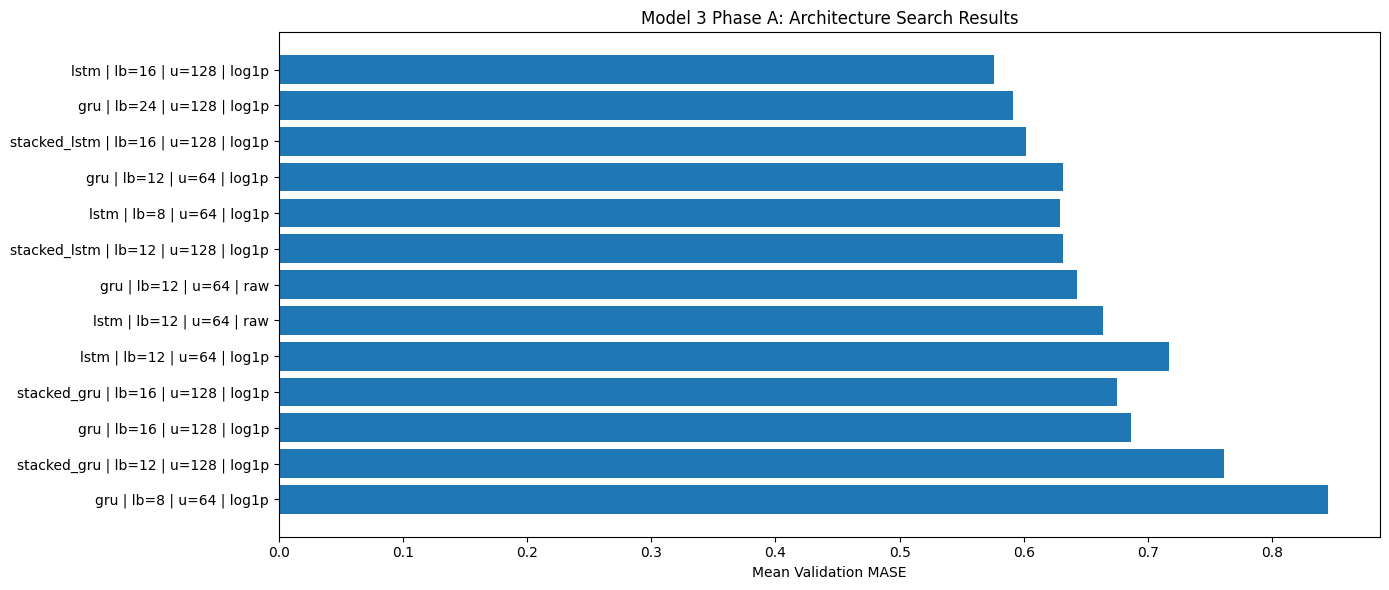

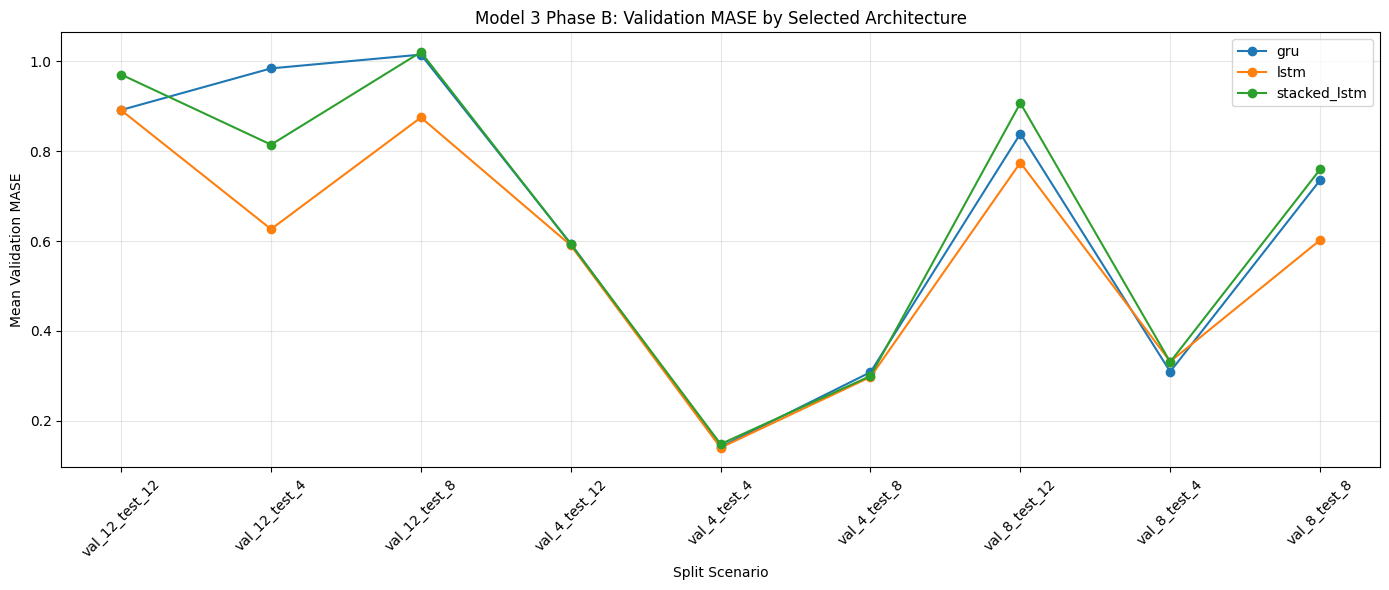

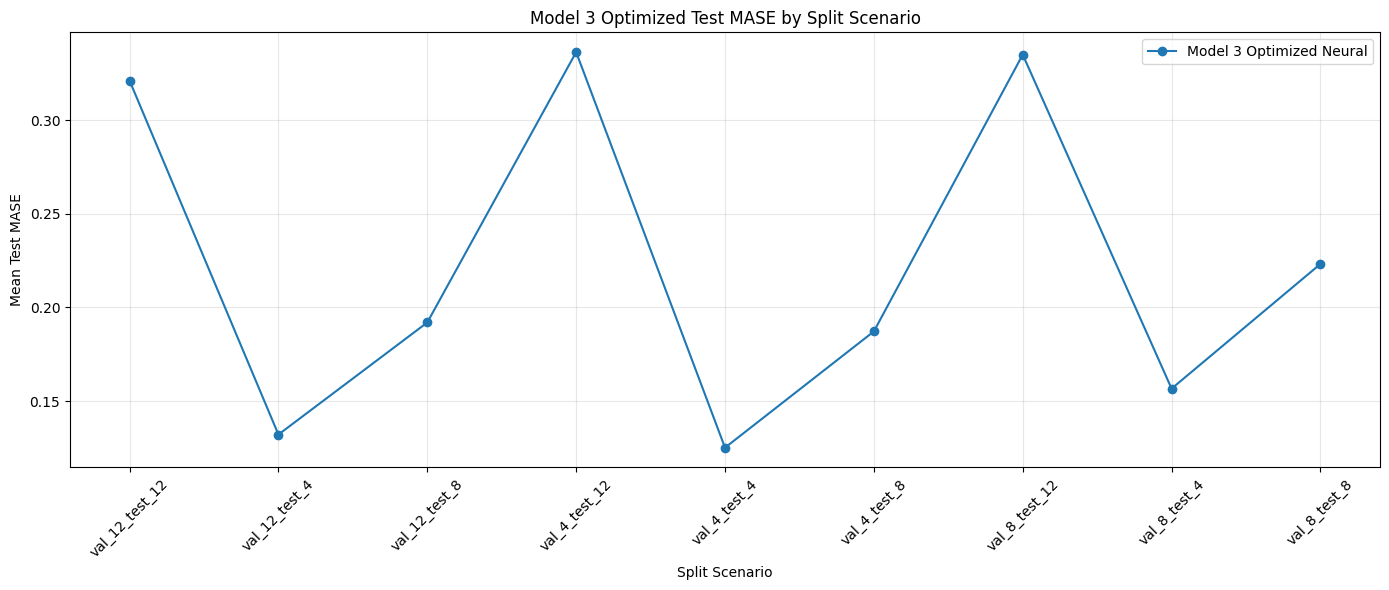

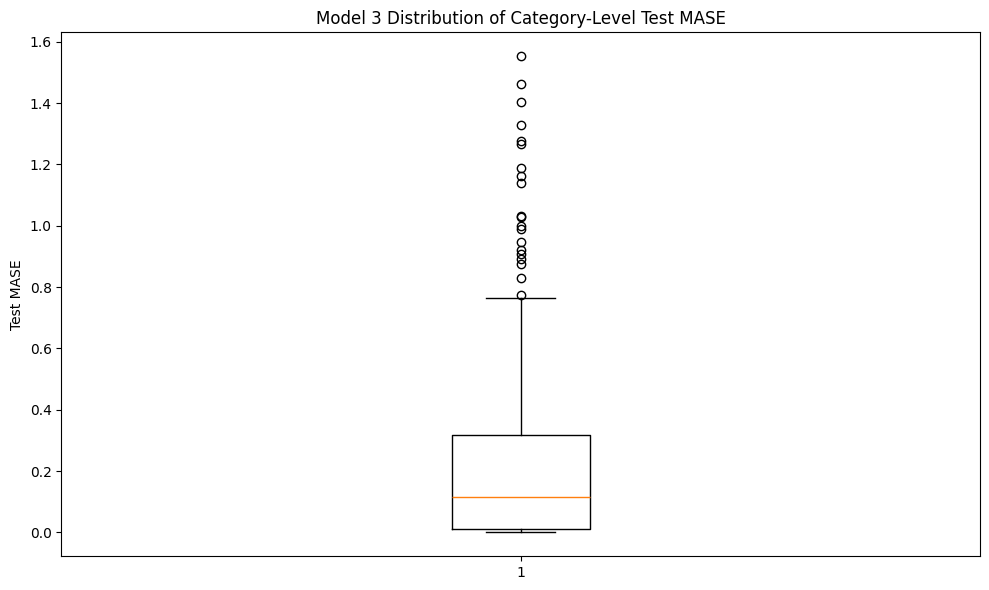

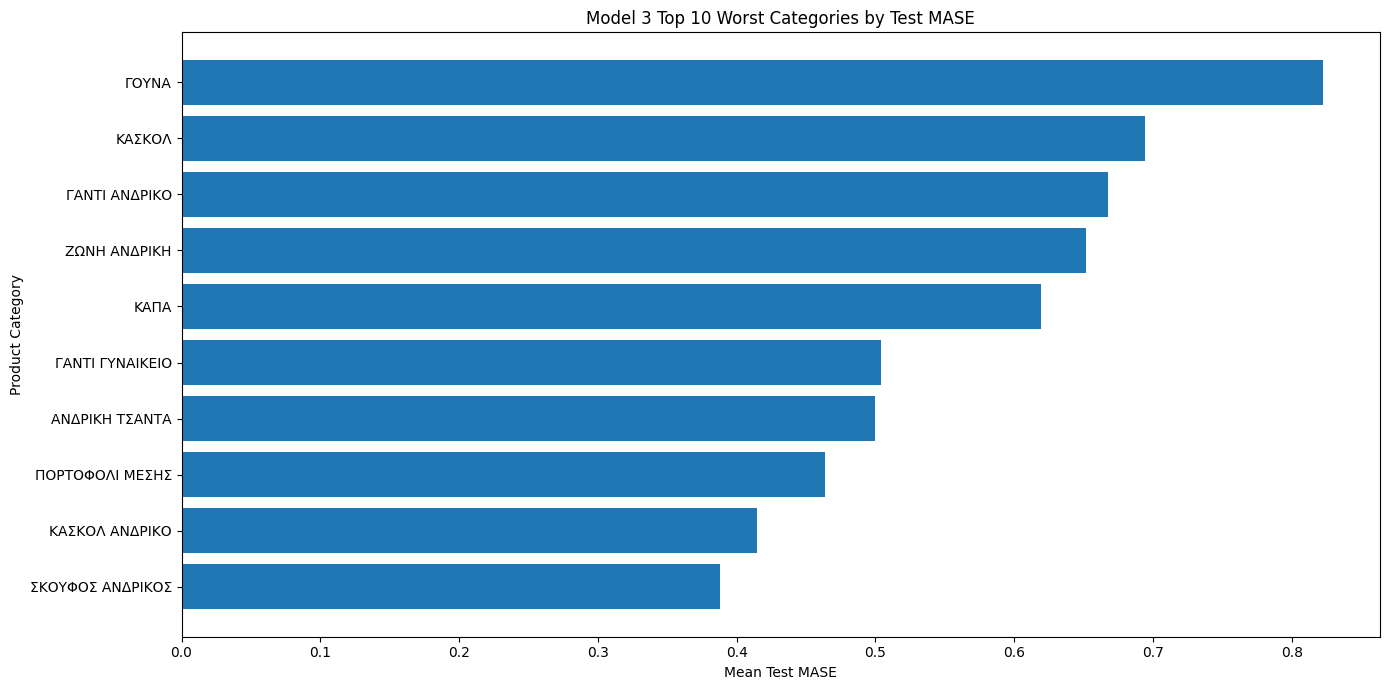

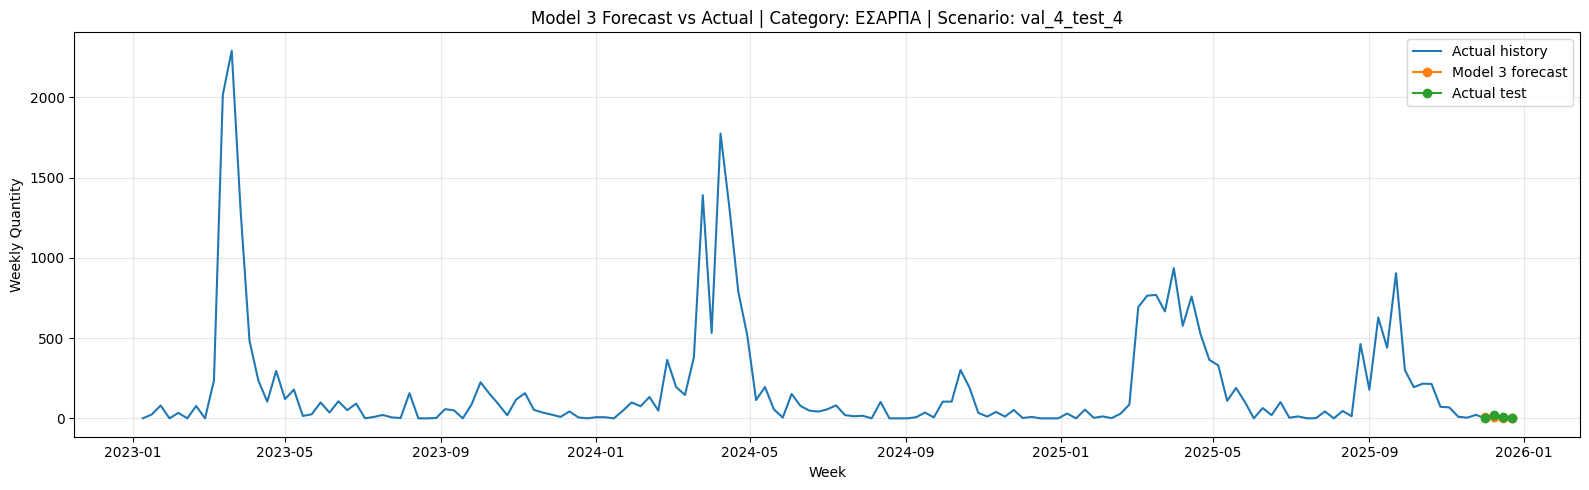

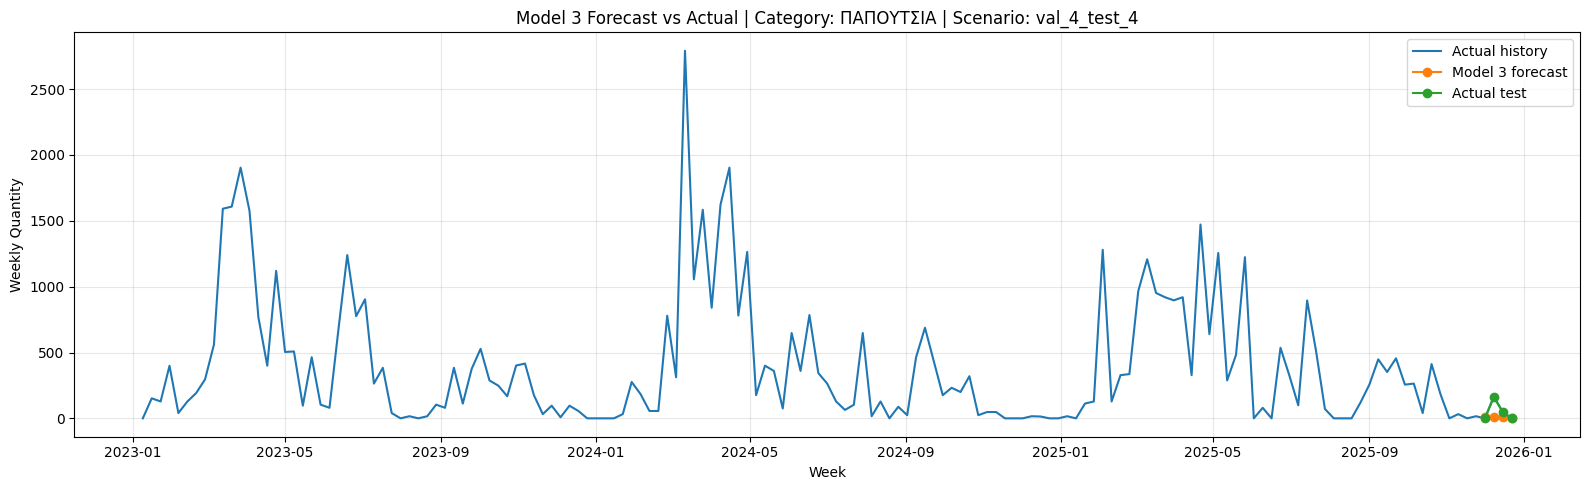

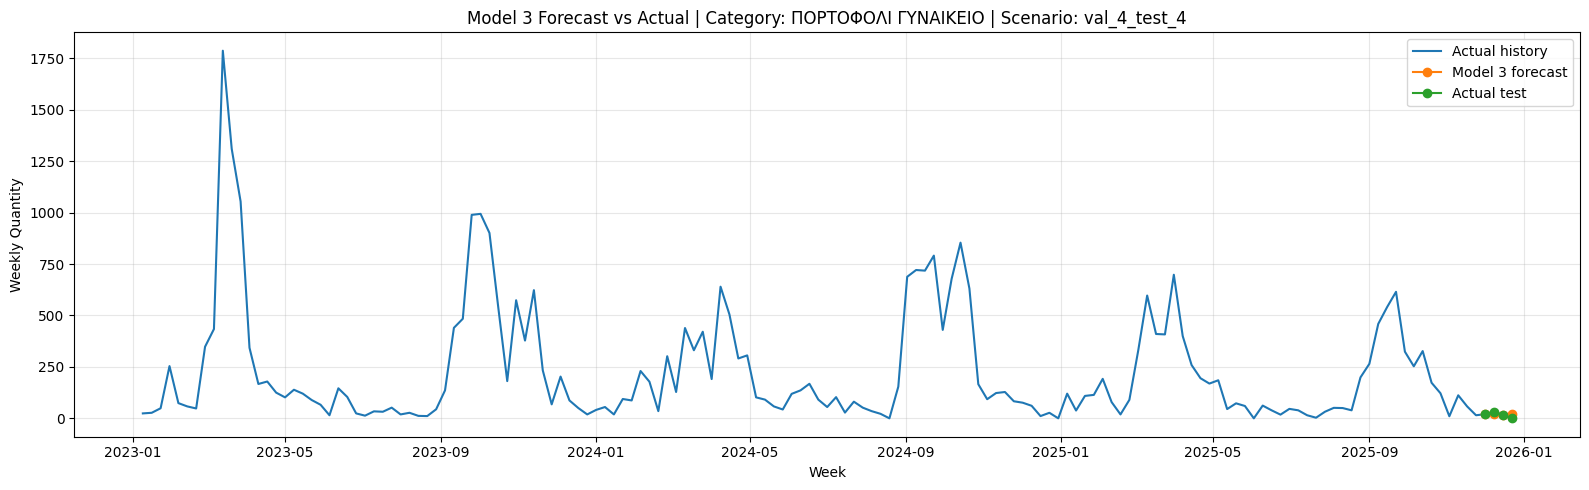

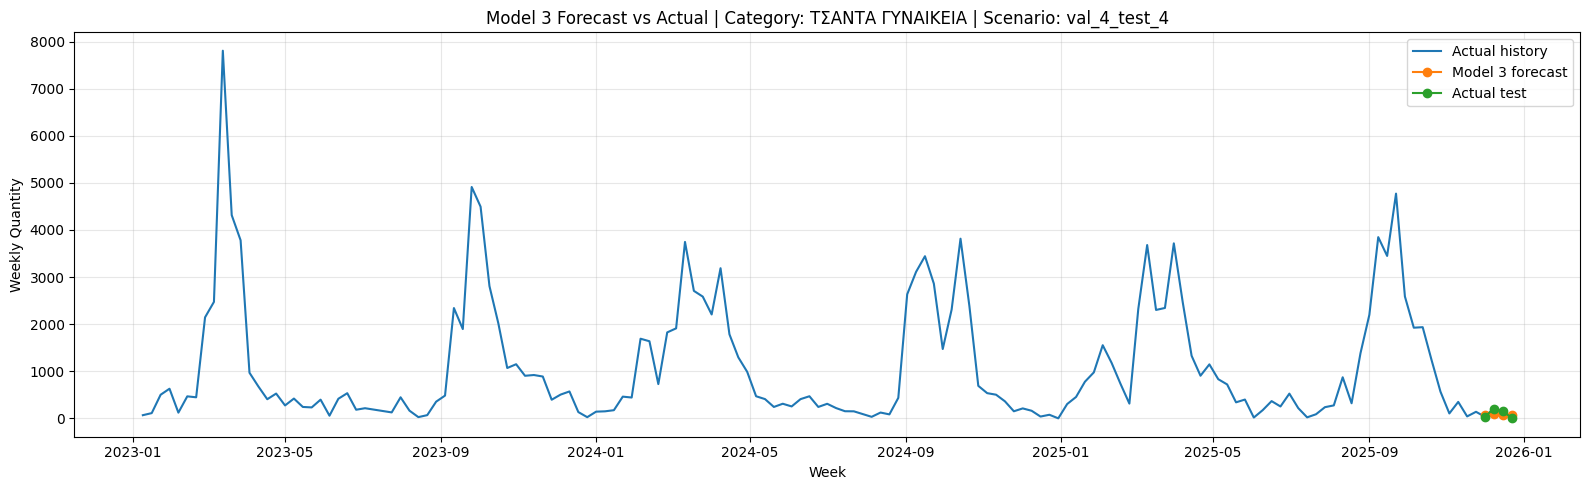

In [16]:
plt.figure(figsize=(14, 6))
plot_df = phase_a_results_df.sort_values('mean_validation_MASE')
labels = plot_df.apply(lambda r: f"{r['architecture']} | lb={int(r['lookback'])} | u={int(r['units'])} | {r['target_transform']}", axis=1)
plt.barh(labels, plot_df['mean_validation_MASE'])
plt.gca().invert_yaxis()
plt.title('Model 3 Phase A: Architecture Search Results')
plt.xlabel('Mean Validation MASE')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_model_3_phase_a_architecture_search.png'), dpi=150)
plt.show()

if not phase_b_validation_df.empty:
    val_arch = (
        phase_b_validation_df
        .groupby(['scenario', 'architecture'], as_index=False)['MASE']
        .mean()
    )
    plt.figure(figsize=(14, 6))
    for architecture in val_arch['architecture'].unique():
        sub = val_arch[val_arch['architecture'] == architecture]
        plt.plot(sub['scenario'], sub['MASE'], marker='o', label=architecture)
    plt.title('Model 3 Phase B: Validation MASE by Selected Architecture')
    plt.xlabel('Split Scenario')
    plt.ylabel('Mean Validation MASE')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'plot_model_3_phase_b_validation_by_architecture.png'), dpi=150)
    plt.show()

scenario_test = phase_b_test_df.groupby('scenario', as_index=False)['MASE'].mean()
plt.figure(figsize=(14, 6))
plt.plot(scenario_test['scenario'], scenario_test['MASE'], marker='o', label='Model 3 Optimized Neural')
plt.title('Model 3 Optimized Test MASE by Split Scenario')
plt.xlabel('Split Scenario')
plt.ylabel('Mean Test MASE')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_model_3_test_mase_by_scenario.png'), dpi=150)
plt.show()

plt.figure(figsize=(10, 6))
plt.boxplot(phase_b_test_df['MASE'].dropna())
plt.title('Model 3 Distribution of Category-Level Test MASE')
plt.ylabel('Test MASE')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_model_3_category_mase_distribution.png'), dpi=150)
plt.show()

worst_categories = (
    phase_b_test_df
    .groupby('Product Category', as_index=False)['MASE']
    .mean()
    .sort_values('MASE', ascending=False)
    .head(10)
)
plt.figure(figsize=(14, 7))
plt.barh(worst_categories['Product Category'], worst_categories['MASE'])
plt.gca().invert_yaxis()
plt.title('Model 3 Top 10 Worst Categories by Test MASE')
plt.xlabel('Mean Test MASE')
plt.ylabel('Product Category')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_model_3_worst_categories.png'), dpi=150)
plt.show()

selected_categories = ['ΑΜΠΙΓΙΕ', 'ΕΣΑΡΠΑ', 'ΚΑΣΚΟΛ', 'ΠΑΠΟΥΤΣΙΑ', 'ΠΟΡΤΟΦΟΛΙ ΓΥΝΑΙΚΕΙΟ', 'ΤΣΑΝΤΑ ΓΥΝΑΙΚΕΙΑ']
selected_scenario = 'val_4_test_4'

for category in selected_categories:
    history = category_df[category_df['Product Category'] == category].sort_values('week_start')
    fc = forecast_df[(forecast_df['Product Category'] == category) & (forecast_df['scenario'] == selected_scenario)]
    if fc.empty:
        continue

    plt.figure(figsize=(16, 5))
    plt.plot(history['week_start'], history['weekly_quantity'], label='Actual history')
    plt.plot(fc['week_start'], fc['forecast'], marker='o', label='Model 3 forecast')
    plt.plot(fc['week_start'], fc['actual'], marker='o', label='Actual test')
    plt.title(f'Model 3 Forecast vs Actual | Category: {category} | Scenario: {selected_scenario}')
    plt.xlabel('Week')
    plt.ylabel('Weekly Quantity')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    safe_category = str(category).replace('/', '_').replace(' ', '_')
    plt.savefig(os.path.join(OUTPUT_DIR, f'plot_model_3_forecast_{safe_category}.png'), dpi=150)
    plt.show()

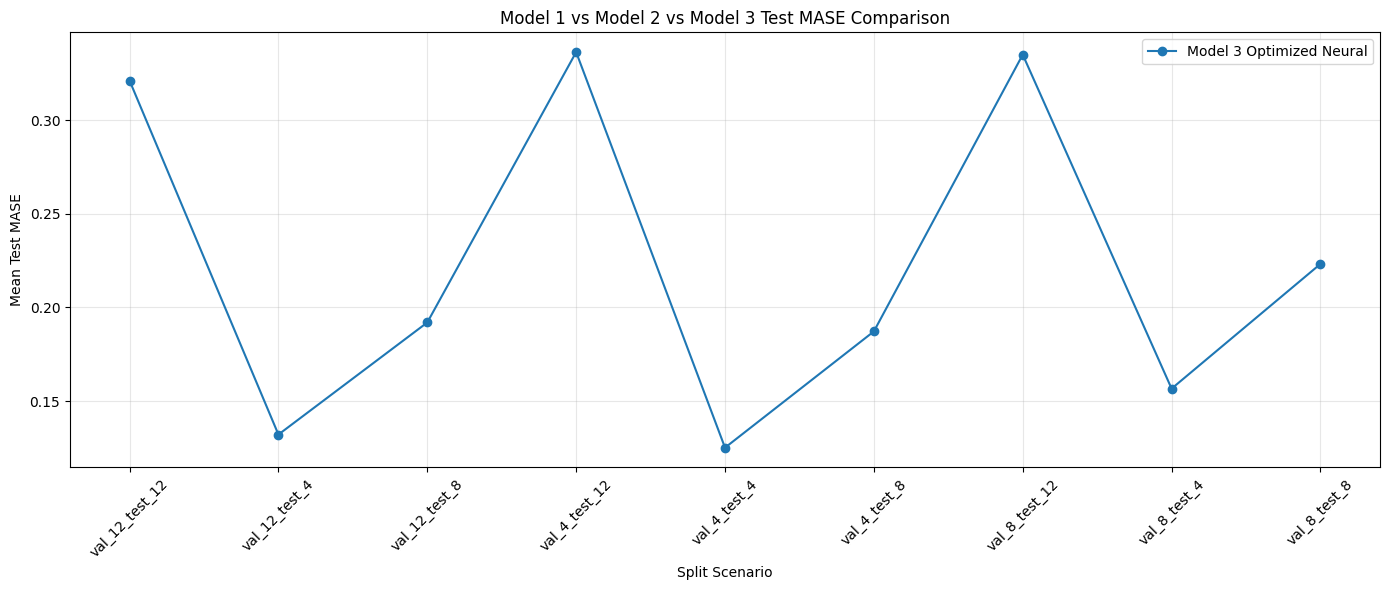

In [17]:
comparison_frames = []

if MODEL_1_FILE is not None:
    m1 = pd.read_csv(MODEL_1_FILE)
    if 'scenario' in m1.columns and 'MASE' in m1.columns:
        comparison_frames.append(m1.groupby('scenario', as_index=False)['MASE'].mean().assign(model='Model 1 Statistical'))

if MODEL_2_FILE is not None:
    m2 = pd.read_csv(MODEL_2_FILE)
    if 'scenario' in m2.columns and 'MASE' in m2.columns:
        comparison_frames.append(m2.groupby('scenario', as_index=False)['MASE'].mean().assign(model='Model 2 Tree-Based ML'))

m3 = phase_b_test_df.groupby('scenario', as_index=False)['MASE'].mean().assign(model='Model 3 Optimized Neural')
comparison_frames.append(m3)

comparison_df = pd.concat(comparison_frames, ignore_index=True)
comparison_df.to_csv(os.path.join(OUTPUT_DIR, 'model_1_vs_model_2_vs_model_3_comparison.csv'), index=False, encoding='utf-8-sig')

plt.figure(figsize=(14, 6))
for model_name in comparison_df['model'].unique():
    sub = comparison_df[comparison_df['model'] == model_name]
    plt.plot(sub['scenario'], sub['MASE'], marker='o', label=model_name)
plt.title('Model 1 vs Model 2 vs Model 3 Test MASE Comparison')
plt.xlabel('Split Scenario')
plt.ylabel('Mean Test MASE')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_model_1_vs_model_2_vs_model_3_comparison.png'), dpi=150)
plt.show()

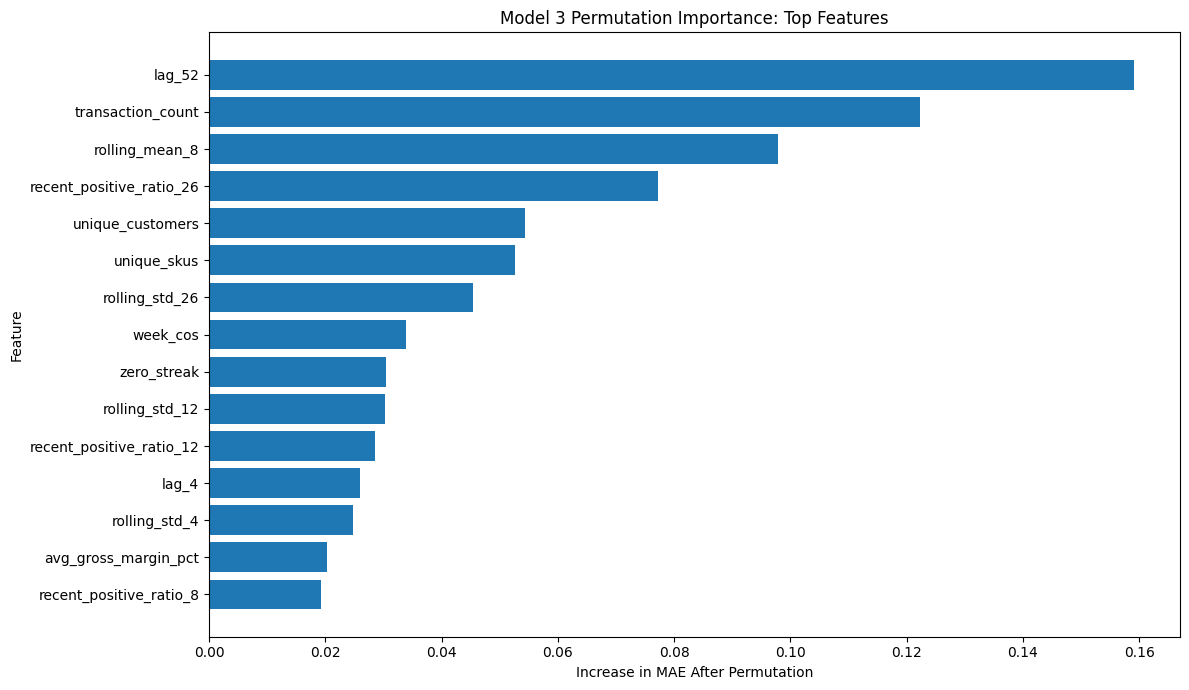

In [18]:
importance_records = []
importance_scenario = 'val_4_test_4'
importance_config_row = phase_b_best_configs_df[phase_b_best_configs_df['scenario'] == importance_scenario]

if not importance_config_row.empty:
    config = importance_config_row.iloc[0].to_dict()
    split = [s for s in split_scenarios if s['scenario'] == importance_scenario][0]
    val_start, test_start = get_split_dates(category_df, split['validation_horizon'], split['test_horizon'])
    horizon = split['test_horizon']

    train_val_df = category_df[category_df['week_start'] < test_start].copy()
    scaler = StandardScaler() if config['scaler'] == 'standard' else MinMaxScaler()
    scaler.fit(train_val_df[feature_cols])

    scaled_df = category_df.copy()
    scaled_df[feature_cols] = scaler.transform(scaled_df[feature_cols])

    X_num, X_cat, y, meta = create_direct_sequences(
        scaled_df,
        feature_cols,
        lookback=int(config['lookback']),
        horizon=horizon,
        target_transform=config['target_transform']
    )

    train_val_mask = meta['forecast_start'] < test_start
    test_mask = meta['forecast_start'] == test_start

    X_tv_num, X_tv_cat, y_tv = X_num[train_val_mask], X_cat[train_val_mask], y[train_val_mask]
    X_test_num, X_test_cat, y_test = X_num[test_mask], X_cat[test_mask], y[test_mask]

    if len(X_test_num) > 0:
        tf.keras.backend.clear_session()
        model = build_model(
            architecture=config['architecture'],
            lookback=int(config['lookback']),
            n_features=len(feature_cols),
            n_categories=n_categories,
            horizon=horizon,
            units=int(config['units']),
            dropout=float(config['dropout']),
            lr=float(config['lr']),
            embedding_dim=int(config['embedding_dim'])
        )

        internal_val_size = max(1, int(0.15 * len(X_tv_num)))
        model.fit(
            [X_tv_num[:-internal_val_size], X_tv_cat[:-internal_val_size]],
            y_tv[:-internal_val_size],
            validation_data=([X_tv_num[-internal_val_size:], X_tv_cat[-internal_val_size:]], y_tv[-internal_val_size:]),
            epochs=50,
            batch_size=int(config['batch_size']),
            callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
            verbose=0
        )

        base_pred = model.predict([X_test_num, X_test_cat], verbose=0)
        base_pred = inverse_transform_target(base_pred, config['target_transform'])
        base_actual = inverse_transform_target(y_test, config['target_transform'])
        base_error = mean_absolute_error(base_actual.reshape(-1), base_pred.reshape(-1))

        rng = np.random.default_rng(SEED)
        for feature_idx, feature_name in enumerate(feature_cols):
            X_perm = X_test_num.copy()
            flat_values = X_perm[:, :, feature_idx].reshape(-1)
            rng.shuffle(flat_values)
            X_perm[:, :, feature_idx] = flat_values.reshape(X_perm[:, :, feature_idx].shape)

            perm_pred = model.predict([X_perm, X_test_cat], verbose=0)
            perm_pred = inverse_transform_target(perm_pred, config['target_transform'])
            perm_error = mean_absolute_error(base_actual.reshape(-1), perm_pred.reshape(-1))

            importance_records.append({
                'scenario': importance_scenario,
                'feature': feature_name,
                'baseline_MAE': base_error,
                'permuted_MAE': perm_error,
                'increase_in_MAE': perm_error - base_error
            })

importance_df = pd.DataFrame(importance_records)
if not importance_df.empty:
    importance_df = importance_df.sort_values('increase_in_MAE', ascending=False)
    importance_df.to_csv(os.path.join(OUTPUT_DIR, 'model_3_permutation_importance.csv'), index=False, encoding='utf-8-sig')

    top_importance = importance_df.head(15)
    plt.figure(figsize=(12, 7))
    plt.barh(top_importance['feature'], top_importance['increase_in_MAE'])
    plt.gca().invert_yaxis()
    plt.title('Model 3 Permutation Importance: Top Features')
    plt.xlabel('Increase in MAE After Permutation')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'plot_model_3_permutation_importance.png'), dpi=150)
    plt.show()

In [19]:
print('\nFinal validation checks')
print('Phase A experiments completed:', len(phase_a_results_df))
print('Phase B validation rows:', len(phase_b_validation_df))
print('Phase B test rows:', len(phase_b_test_df))
print('Forecast rows:', len(forecast_df))
print('Unique test scenarios:', phase_b_test_df['scenario'].nunique())
print('Unique categories:', phase_b_test_df['Product Category'].nunique())
print('\nMean test MASE by scenario:')
print(phase_b_test_df.groupby('scenario')['MASE'].mean().sort_index())

if forecast_df['forecast'].isna().any():
    raise ValueError('Forecast file contains NaN forecasts.')

if (forecast_df['forecast'] < 0).any():
    raise ValueError('Forecast file contains negative forecasts.')

print('\nModel 3 optimized neural forecasting completed successfully.')


Final validation checks
Phase A experiments completed: 15
Phase B validation rows: 1080
Phase B test rows: 360
Forecast rows: 2880
Unique test scenarios: 9
Unique categories: 40

Mean test MASE by scenario:
scenario
val_12_test_12    0.321072
val_12_test_4     0.132094
val_12_test_8     0.191942
val_4_test_12     0.336307
val_4_test_4      0.125088
val_4_test_8      0.187172
val_8_test_12     0.334948
val_8_test_4      0.156610
val_8_test_8      0.223199
Name: MASE, dtype: float64

Model 3 optimized neural forecasting completed successfully.
